# CAMELS-SIMBA Graph Model Results: 20U to 500U

This notebook summarizes the current graph-based experiments for predicting the cosmological parameter $\Omega_m$ from CAMELS-SIMBA halo graphs.

The comparison focuses only on graph models:

- **Static GCN**: uses one final-snapshot graph per universe.
- **EvolveGCN-H**: uses a temporal sequence of halo graphs across multiple snapshots.

The simple mean baseline is intentionally excluded because it does not use graph structure and is no longer part of the main result comparison.

## Research snapshot status

This notebook is a dated 20U–500U graph-model research snapshot assembled from the then-current experiment summary. It includes historical families that must not be mixed with the final controlled protocol. Final thesis tables will be regenerated from verified experiment artifacts.

In [19]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Project-root paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parents[1]

SUMMARY_PATH = PROJECT_ROOT / "outputs/notebook_tables/graph_models_20u_to_500u_no_baseline.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs/notebook_figures/graph_models_20u_to_500u_no_baseline"
TABLE_DIR = PROJECT_ROOT / "outputs/notebook_tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Small plotting helper
# ------------------------------------------------------------
def save_current_figure(name: str):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved figure: {path}")


print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Summary path:", SUMMARY_PATH)
print("Summary exists:", SUMMARY_PATH.exists())

Current working directory: <REPO_ROOT>/notebooks/visualization
Project root: <REPO_ROOT>
Summary path: <REPO_ROOT>/outputs/notebook_tables/graph_models_20u_to_500u_no_baseline.csv
Summary exists: True


## 1. Loading the experiment summary

The summary table was generated from the `metrics.json` files saved inside each experiment folder.

Each row represents one trained experiment, including:

- dataset size,
- model type,
- random seed,
- train/validation/test metrics,
- best epoch,
- number of trainable parameters.

The key evaluation metrics are:

- **MAE**: mean absolute prediction error. Lower is better.
- **RMSE**: root mean squared error. Lower is better and penalizes large mistakes more strongly.

In [20]:
df = pd.read_csv(SUMMARY_PATH)

# Remove baseline rows if any accidentally exist
df = df[~df["model"].astype(str).str.contains("baseline", case=False, na=False)].copy()

# Extract numeric dataset size from labels like "20U", "500U"
df["num_universes_clean"] = (
    df["dataset_size"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

# Standardize sorting
df = df.sort_values(
    by=["num_universes_clean", "model", "seed"]
).reset_index(drop=True)

print("Rows:", len(df))
print("Dataset sizes:", sorted(df["dataset_size"].dropna().unique()))
print("Models:", sorted(df["model"].dropna().unique()))

display(df)

Rows: 30
Dataset sizes: ['100U', '200U', '20U', '500U', '50U']
Models: ['EvolveGCN-H', 'Static GCN']


,experiment_name,model,model_key,num_universes,dataset_size,seed,train_mse,train_rmse,train_mae,train_samples,...,test_rmse,test_mae,test_samples,best_epoch,best_val_mse,trainable_parameters,train_mean_omega_m,experiment_dir,metrics_path,num_universes_clean
0,evolvegcn_h_20u_seed42,EvolveGCN-H,evolvegcn_h,20,20U,42,0.012965,0.113865,0.096091,14,...,0.102973,0.094632,3,28,0.011934,3409153,NaN,experiments/evolvegcn_h_20u_seed42,experiments/evolvegcn_h_20u_seed42/metrics.json,20.0
1,evolvegcn_h_20u_seed123_final32,EvolveGCN-H,evolvegcn_h,20,20U,123,0.015586,0.124842,0.106239,14,...,0.112434,0.105891,3,19,0.008311,3409153,NaN,experiments/evolvegcn_h_20u_seed123_final32,experiments/evolvegcn_h_20u_seed123_final32/me...,20.0
2,evolvegcn_h_20u_seed2025,EvolveGCN-H,evolvegcn_h,20,20U,2025,0.014747,0.121436,0.102815,14,...,0.118320,0.101023,3,2,0.011030,3409153,NaN,experiments/evolvegcn_h_20u_seed2025,experiments/evolvegcn_h_20u_seed2025/metrics.json,20.0
3,static_gcn_20u_seed42,Static GCN,static_gcn,20,20U,42,0.028080,0.167572,0.130568,14,...,0.131345,0.103511,3,12,0.010781,4161,NaN,experiments/static_gcn_20u_seed42,experiments/static_gcn_20u_seed42/metrics.json,20.0
4,static_gcn_20u_seed123_final32,Static GCN,static_gcn,20,20U,123,0.016943,0.130163,0.114610,14,...,0.132410,0.121738,3,10,0.007556,4161,NaN,experiments/static_gcn_20u_seed123_final32,experiments/static_gcn_20u_seed123_final32/met...,20.0
5,static_gcn_20u_seed2025,Static GCN,static_gcn,20,20U,2025,0.041454,0.203602,0.167711,14,...,0.211951,0.211519,3,7,0.014834,4161,NaN,experiments/static_gcn_20u_seed2025,experiments/static_gcn_20u_seed2025/metrics.json,20.0
6,evolvegcn_h_50u_seed42,EvolveGCN-H,evolvegcn_h,50,50U,42,0.010423,0.102092,0.084140,35,...,0.114216,0.093515,8,59,0.014983,3409153,NaN,experiments/evolvegcn_h_50u_seed42,experiments/evolvegcn_h_50u_seed42/metrics.json,50.0
7,evolvegcn_h_50u_seed123_final32,EvolveGCN-H,evolvegcn_h,50,50U,123,0.014161,0.118998,0.099727,35,...,0.121001,0.102472,8,8,0.005092,3409153,NaN,experiments/evolvegcn_h_50u_seed123_final32,experiments/evolvegcn_h_50u_seed123_final32/me...,50.0
8,evolvegcn_h_50u_seed2025,EvolveGCN-H,evolvegcn_h,50,50U,2025,0.012515,0.111871,0.092466,35,...,0.138901,0.127385,8,2,0.011440,3409153,NaN,experiments/evolvegcn_h_50u_seed2025,experiments/evolvegcn_h_50u_seed2025/metrics.json,50.0
9,static_gcn_50u_seed42,Static GCN,static_gcn,50,50U,42,0.013457,0.116006,0.095704,35,...,0.109976,0.099470,8,36,0.015937,4161,NaN,experiments/static_gcn_50u_seed42,experiments/static_gcn_50u_seed42/metrics.json,50.0


## 2. Full experiment table

This table shows all completed graph experiments.

For each dataset size, both graph models were trained using multiple random seeds. This helps us check whether the result is stable or only caused by one lucky/unlucky split.

In [21]:
meeting_cols = [
    "dataset_size",
    "model",
    "seed",
    "train_mae",
    "val_mae",
    "test_mae",
    "test_rmse",
    "best_epoch",
    "trainable_parameters",
    "experiment_name",
]

meeting_table = df[meeting_cols].copy()

for col in ["train_mae", "val_mae", "test_mae", "test_rmse"]:
    meeting_table[col] = pd.to_numeric(meeting_table[col], errors="coerce").round(6)

display(meeting_table)

meeting_table.to_csv(TABLE_DIR / "meeting_table_graph_models_20u_to_500u.csv", index=False)

,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
0,20U,EvolveGCN-H,42,0.096091,0.099446,0.094632,0.102973,28,3409153,evolvegcn_h_20u_seed42
1,20U,EvolveGCN-H,123,0.106239,0.079218,0.105891,0.112434,19,3409153,evolvegcn_h_20u_seed123_final32
2,20U,EvolveGCN-H,2025,0.102815,0.103417,0.101023,0.118320,2,3409153,evolvegcn_h_20u_seed2025
3,20U,Static GCN,42,0.130568,0.101160,0.103511,0.131345,12,4161,static_gcn_20u_seed42
4,20U,Static GCN,123,0.114610,0.063471,0.121738,0.132410,10,4161,static_gcn_20u_seed123_final32
5,20U,Static GCN,2025,0.167711,0.085706,0.211519,0.211951,7,4161,static_gcn_20u_seed2025
6,50U,EvolveGCN-H,42,0.084140,0.112418,0.093515,0.114216,59,3409153,evolvegcn_h_50u_seed42
7,50U,EvolveGCN-H,123,0.099727,0.058946,0.102472,0.121001,8,3409153,evolvegcn_h_50u_seed123_final32
8,50U,EvolveGCN-H,2025,0.092466,0.090177,0.127385,0.138901,2,3409153,evolvegcn_h_50u_seed2025
9,50U,Static GCN,42,0.095704,0.117785,0.099470,0.109976,36,4161,static_gcn_50u_seed42


## 3. Average performance across seeds

Because each model was trained with multiple random seeds, we summarize the result using the mean and standard deviation.

The mean shows the average performance, while the standard deviation shows how stable the model is across different seeds.

A good model should ideally have:

- low average error,
- low variation across seeds,
- consistent behavior as the dataset size increases.

In [22]:
summary_by_model = (
    df
    .groupby(["num_universes_clean", "dataset_size", "model"], as_index=False)
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        val_mae_mean=("val_mae", "mean"),
        train_mae_mean=("train_mae", "mean"),
        runs=("seed", "count"),
        trainable_parameters=("trainable_parameters", "mean"),
    )
    .sort_values(["num_universes_clean", "model"])
)

round_cols = [
    "test_mae_mean",
    "test_mae_std",
    "test_rmse_mean",
    "test_rmse_std",
    "val_mae_mean",
    "train_mae_mean",
]

summary_by_model[round_cols] = summary_by_model[round_cols].round(6)

display(summary_by_model)

summary_by_model.to_csv(
    TABLE_DIR / "summary_by_model_graph_models_20u_to_500u.csv",
    index=False,
)

,num_universes_clean,dataset_size,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,val_mae_mean,train_mae_mean,runs,trainable_parameters
0,20.0,20U,EvolveGCN-H,0.100515,0.005647,0.111242,0.007742,0.094027,0.101715,3,3409153.0
1,20.0,20U,Static GCN,0.145589,0.057819,0.158569,0.046234,0.083445,0.137630,3,4161.0
2,50.0,50U,EvolveGCN-H,0.107791,0.017550,0.124706,0.012753,0.087180,0.092111,3,3409153.0
3,50.0,50U,Static GCN,0.101764,0.003397,0.116566,0.008410,0.085922,0.107356,3,4161.0
4,100.0,100U,EvolveGCN-H,0.097874,0.024946,0.118388,0.022933,0.103119,0.094033,3,3409153.0
5,100.0,100U,Static GCN,0.090691,0.016841,0.111571,0.010549,0.101898,0.097153,3,4161.0
6,200.0,200U,EvolveGCN-H,0.100152,0.013588,0.115273,0.012270,0.083992,0.099877,3,3409153.0
7,200.0,200U,Static GCN,0.101222,0.013152,0.118935,0.012820,0.086408,0.105749,3,4161.0
8,500.0,500U,EvolveGCN-H,0.096962,0.009492,0.113241,0.009904,0.097167,0.096356,3,3409153.0
9,500.0,500U,Static GCN,0.099009,0.012167,0.115039,0.012190,0.096616,0.098917,3,4161.0


## 4. Test MAE scaling from 20U to 500U

This plot shows how the test MAE changes as the number of universes increases.

The goal is to check whether increasing the dataset size improves generalization.

Lower Test MAE is better.

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/01_test_mae_scaling_20u_to_500u.png


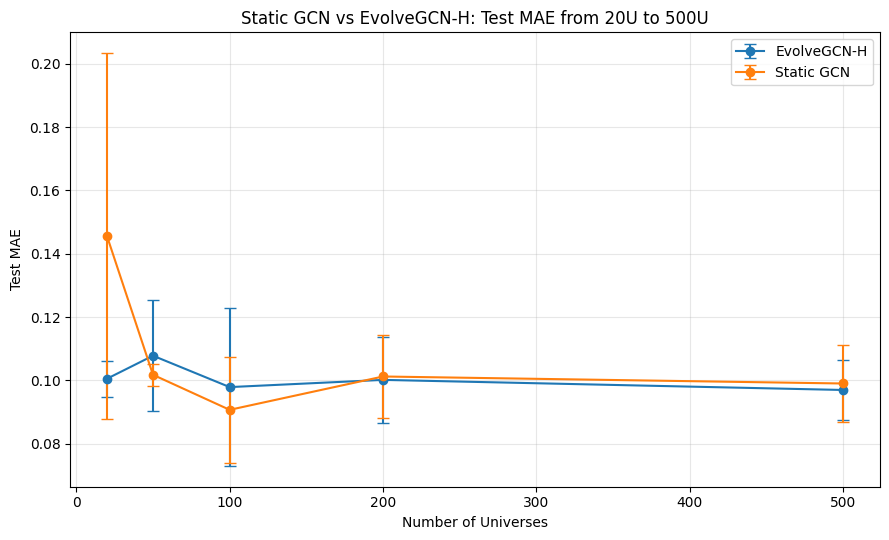

In [23]:
plt.figure(figsize=(9, 5.5))

for model_name, model_df in summary_by_model.groupby("model"):
    model_df = model_df.sort_values("num_universes_clean")

    plt.errorbar(
        model_df["num_universes_clean"],
        model_df["test_mae_mean"],
        yerr=model_df["test_mae_std"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel("Number of Universes")
plt.ylabel("Test MAE")
plt.title("Static GCN vs EvolveGCN-H: Test MAE from 20U to 500U")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("01_test_mae_scaling_20u_to_500u.png")
plt.show()

## 5. Test RMSE scaling from 20U to 500U

RMSE penalizes large prediction errors more strongly than MAE.

This plot helps us check whether a model sometimes makes large mistakes, even if its average absolute error looks reasonable.

Lower Test RMSE is better.

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/02_test_rmse_scaling_20u_to_500u.png


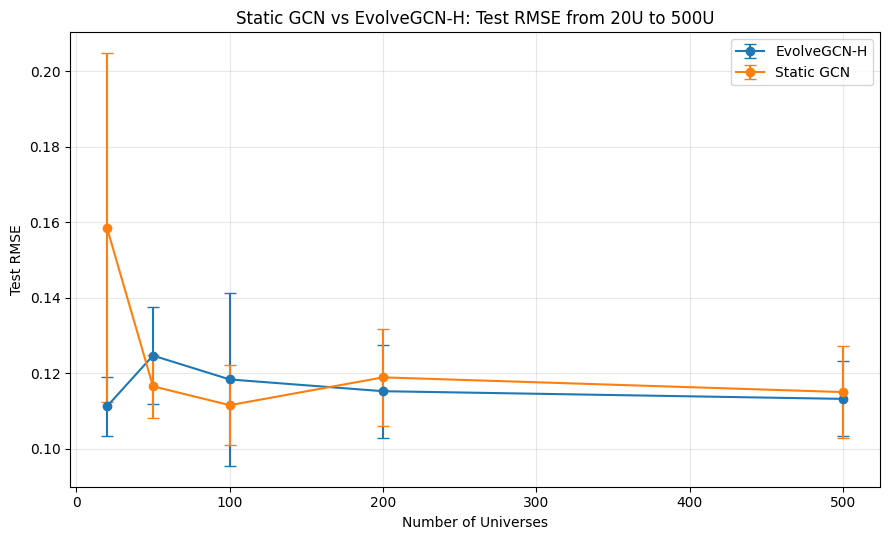

In [24]:
plt.figure(figsize=(9, 5.5))

for model_name, model_df in summary_by_model.groupby("model"):
    model_df = model_df.sort_values("num_universes_clean")

    plt.errorbar(
        model_df["num_universes_clean"],
        model_df["test_rmse_mean"],
        yerr=model_df["test_rmse_std"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel("Number of Universes")
plt.ylabel("Test RMSE")
plt.title("Static GCN vs EvolveGCN-H: Test RMSE from 20U to 500U")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("02_test_rmse_scaling_20u_to_500u.png")
plt.show()

## 6. Best model per dataset size

This table identifies which graph model performed best for each dataset size based on the lowest average Test MAE.

This gives a compact summary of whether the static graph model or the temporal graph model is currently stronger.

In [25]:
best_per_size = (
    summary_by_model
    .sort_values(["num_universes_clean", "test_mae_mean"])
    .groupby("dataset_size", as_index=False)
    .first()
)

best_per_size = best_per_size[
    [
        "dataset_size",
        "model",
        "test_mae_mean",
        "test_mae_std",
        "test_rmse_mean",
        "test_rmse_std",
        "runs",
        "trainable_parameters",
    ]
]

display(best_per_size)

best_per_size.to_csv(
    TABLE_DIR / "best_model_per_dataset_size_graph_models.csv",
    index=False,
)

,dataset_size,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs,trainable_parameters
0,100U,Static GCN,0.090691,0.016841,0.111571,0.010549,3,4161.0
1,200U,EvolveGCN-H,0.100152,0.013588,0.115273,0.012270,3,3409153.0
2,20U,EvolveGCN-H,0.100515,0.005647,0.111242,0.007742,3,3409153.0
3,500U,EvolveGCN-H,0.096962,0.009492,0.113241,0.009904,3,3409153.0
4,50U,Static GCN,0.101764,0.003397,0.116566,0.008410,3,4161.0


## 7. Focus on 500U experiments

The 500U experiments are currently the most important because they use the largest dataset size tested so far.

This table compares Static GCN and EvolveGCN-H on 500 universes across the same three random seeds.

In [26]:
df_500 = df[df["num_universes_clean"] == 500].copy()

cols_500 = [
    "dataset_size",
    "model",
    "seed",
    "train_mae",
    "val_mae",
    "test_mae",
    "test_rmse",
    "best_epoch",
    "trainable_parameters",
    "experiment_name",
]

display(df_500[cols_500].sort_values(["model", "seed"]))

df_500[cols_500].to_csv(
    TABLE_DIR / "detailed_500u_graph_model_results.csv",
    index=False,
)

,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
24,500U,EvolveGCN-H,42,0.100584,0.093470,0.086537,0.102059,8,3409153,evolvegcn_h_500u_seed42_final32
25,500U,EvolveGCN-H,123,0.091313,0.102181,0.099245,0.116757,65,3409153,evolvegcn_h_500u_seed123_final32
26,500U,EvolveGCN-H,2025,0.097169,0.095850,0.105104,0.120907,5,3409153,evolvegcn_h_500u_seed2025_final32
27,500U,Static GCN,42,0.100926,0.093786,0.086672,0.102034,22,4161,static_gcn_500u_seed42_final32
28,500U,Static GCN,123,0.096950,0.101807,0.099357,0.116878,7,4161,static_gcn_500u_seed123_final32
29,500U,Static GCN,2025,0.098875,0.094255,0.110997,0.126205,5,4161,static_gcn_500u_seed2025_final32


## 8. 500U model comparison

This plot compares the average 500U test performance of Static GCN and EvolveGCN-H.

The error bars show how much the result changes across random seeds.

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/03_500u_test_mae_bar_zoomed.png


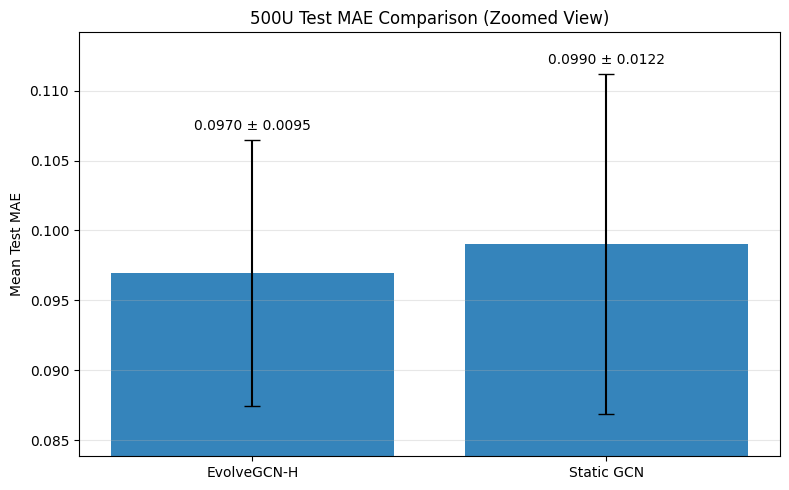

In [38]:
summary_500 = summary_by_model[summary_by_model["num_universes_clean"] == 500].copy()
summary_500 = summary_500.sort_values("test_mae_mean")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_500["model"],
    summary_500["test_mae_mean"],
    yerr=summary_500["test_mae_std"],
    capsize=6,
    alpha=0.9
)

plt.ylabel("Mean Test MAE")
plt.title("500U Test MAE Comparison (Zoomed View)")
plt.grid(True, axis="y", alpha=0.3)

# Zoom the y-axis so small differences are visible
y_min = (summary_500["test_mae_mean"] - summary_500["test_mae_std"]).min()
y_max = (summary_500["test_mae_mean"] + summary_500["test_mae_std"]).max()
padding = 0.003
plt.ylim(y_min - padding, y_max + padding)

# Add exact values on top of bars
for bar, mean_val, std_val in zip(
    bars,
    summary_500["test_mae_mean"],
    summary_500["test_mae_std"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean_val + std_val + 0.0005,
        f"{mean_val:.4f} ± {std_val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

save_current_figure("03_500u_test_mae_bar_zoomed.png")
plt.show()

## 9. True $\Omega_m$ vs predicted $\Omega_m$

This is one of the most important diagnostic plots.

Each point represents one test universe.

- The x-axis is the true cosmological value $\Omega_m$.
- The y-axis is the model prediction.
- The dashed diagonal line represents perfect prediction.

If predictions are good, points should be close to the diagonal line.

This plot is useful because it shows not only the average error, but also whether the model systematically overpredicts or underpredicts.

In [28]:
def load_test_predictions_for_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Load test prediction CSV files for every experiment in the summary table.

    The summary table stores experiment_dir as a project-relative path such as:
        experiments/static_gcn_500u_seed42_final32

    Because this notebook runs inside notebooks/visualization, we must join
    experiment_dir with PROJECT_ROOT.
    """
    rows = []

    for _, row in summary_df.iterrows():
        experiment_name = row["experiment_name"]
        experiment_dir = PROJECT_ROOT / str(row["experiment_dir"])

        prediction_path = experiment_dir / "predictions" / "test_predictions.csv"

        if not prediction_path.exists():
            print(f"Missing prediction file: {prediction_path}")
            continue

        pred_df = pd.read_csv(prediction_path)

        pred_df["dataset_size"] = row["dataset_size"]
        pred_df["num_universes_clean"] = row["num_universes_clean"]
        pred_df["model"] = row["model"]
        pred_df["seed"] = row["seed"]
        pred_df["experiment_name"] = experiment_name

        rows.append(pred_df)

    if not rows:
        print("No prediction files were loaded.")
        return pd.DataFrame(
            columns=[
                "universe_id",
                "true_omega_m",
                "pred_omega_m",
                "absolute_error",
                "squared_error",
                "dataset_size",
                "num_universes_clean",
                "model",
                "seed",
                "experiment_name",
            ]
        )

    return pd.concat(rows, ignore_index=True)


predictions_df = load_test_predictions_for_summary(df)

print("Prediction rows:", len(predictions_df))
display(predictions_df.head())

predictions_df.to_csv(
    TABLE_DIR / "all_test_predictions_graph_models_20u_to_500u.csv",
    index=False,
)

Prediction rows: 786


,universe_id,true_omega_m,pred_omega_m,absolute_error,squared_error,dataset_size,num_universes_clean,model,seed,experiment_name
0,LH_8,0.4018,0.315831,0.085969,0.007391,20U,20.0,EvolveGCN-H,42,evolvegcn_h_20u_seed42
1,LH_0,0.1462,0.294318,0.148118,0.021939,20U,20.0,EvolveGCN-H,42,evolvegcn_h_20u_seed42
2,LH_3,0.2398,0.289609,0.049809,0.002481,20U,20.0,EvolveGCN-H,42,evolvegcn_h_20u_seed42
3,LH_2,0.4226,0.311201,0.111399,0.012410,20U,20.0,EvolveGCN-H,123,evolvegcn_h_20u_seed123_final32
4,LH_8,0.4018,0.344707,0.057093,0.003260,20U,20.0,EvolveGCN-H,123,evolvegcn_h_20u_seed123_final32


Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/04_true_vs_predicted_500u_evolvegcn_h.png


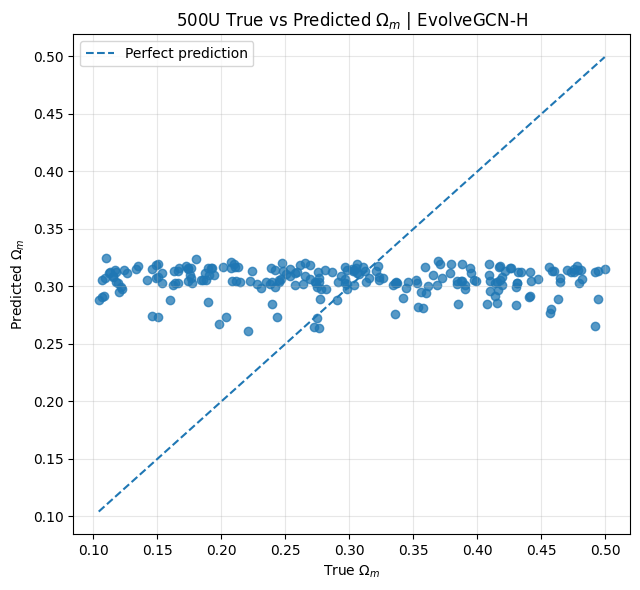

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/04_true_vs_predicted_500u_static_gcn.png


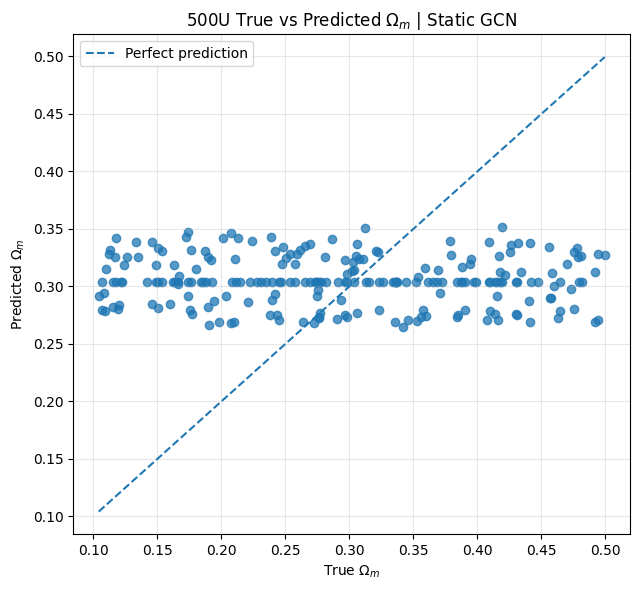

In [29]:
pred_500 = predictions_df[predictions_df["num_universes_clean"] == 500].copy()

if pred_500.empty:
    print("No 500U prediction rows found. Check whether 500U prediction CSV files exist.")
else:
    models = sorted(pred_500["model"].dropna().unique())

    for model_name in models:
        model_pred = pred_500[pred_500["model"] == model_name].copy()

        plt.figure(figsize=(6.5, 6))

        plt.scatter(
            model_pred["true_omega_m"],
            model_pred["pred_omega_m"],
            alpha=0.75,
        )

        min_val = min(
            model_pred["true_omega_m"].min(),
            model_pred["pred_omega_m"].min(),
        )
        max_val = max(
            model_pred["true_omega_m"].max(),
            model_pred["pred_omega_m"].max(),
        )

        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--",
            linewidth=1.5,
            label="Perfect prediction",
        )

        plt.xlabel(r"True $\Omega_m$")
        plt.ylabel(r"Predicted $\Omega_m$")
        plt.title(rf"500U True vs Predicted $\Omega_m$ | {model_name}")
        plt.grid(True, alpha=0.3)
        plt.legend()

        safe_model_name = (
            model_name.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        save_current_figure(f"04_true_vs_predicted_500u_{safe_model_name}.png")
        plt.show()

## 10. Residual analysis

The residual measures the prediction error for each test universe:

$$
\text{Residual} = \hat{\Omega}_m - \Omega_m
$$

where $\hat{\Omega}_m$ is the predicted value and $\Omega_m$ is the true value.

Interpretation:

- residual close to 0 means the prediction is accurate,
- positive residual means the model overpredicts $\Omega_m$,
- negative residual means the model underpredicts $\Omega_m$,
- a visible trend in the residuals means the model has systematic bias.

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/05_residuals_500u_evolvegcn_h.png


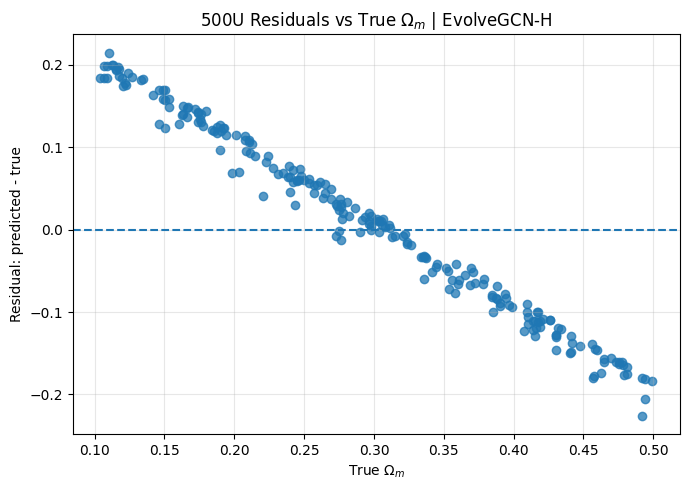

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/05_residuals_500u_static_gcn.png


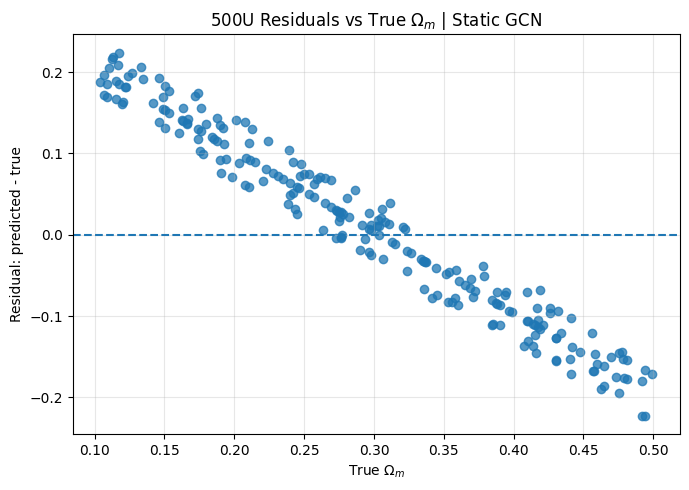

In [30]:
pred_500["residual"] = pred_500["pred_omega_m"] - pred_500["true_omega_m"]

for model_name in models:
    model_pred = pred_500[pred_500["model"] == model_name].copy()

    plt.figure(figsize=(7, 5))

    plt.scatter(
        model_pred["true_omega_m"],
        model_pred["residual"],
        alpha=0.75,
    )

    plt.axhline(0.0, linestyle="--", linewidth=1.5)

    plt.xlabel("True $\\Omega_m$")
    plt.ylabel("Residual: predicted - true")
    plt.title(f"500U Residuals vs True $\\Omega_m$ | {model_name}")
    plt.grid(True, alpha=0.3)

    safe_model_name = model_name.lower().replace(" ", "_").replace("-", "_")
    save_current_figure(f"05_residuals_500u_{safe_model_name}.png")
    plt.show()

## 11. Absolute error distribution

This histogram shows the distribution of absolute prediction errors.

It helps answer:

- Are most errors small?
- Are there a few large mistakes?
- Does one model produce more stable errors than the other?

A better model should have more errors concentrated near zero.

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/06_absolute_error_distribution_500u.png


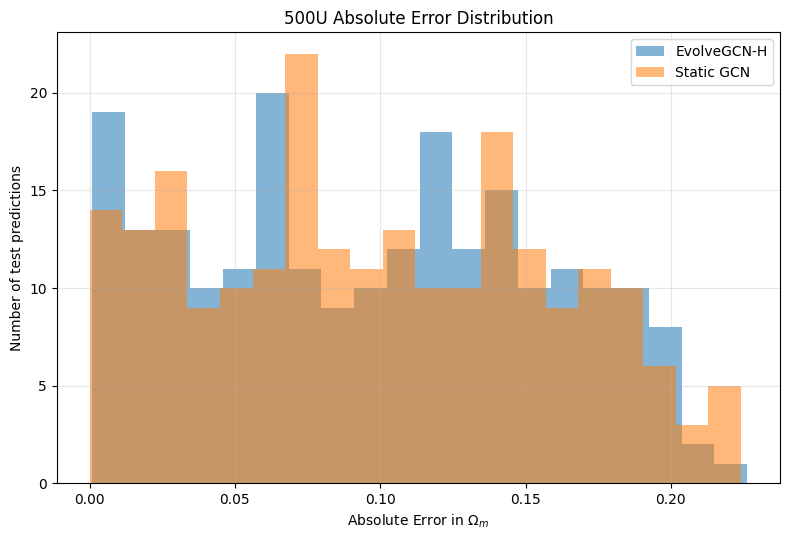

In [31]:
pred_500["absolute_error"] = np.abs(
    pred_500["pred_omega_m"] - pred_500["true_omega_m"]
)

plt.figure(figsize=(8, 5.5))

for model_name in models:
    model_pred = pred_500[pred_500["model"] == model_name]
    plt.hist(
        model_pred["absolute_error"],
        bins=20,
        alpha=0.55,
        label=model_name,
    )

plt.xlabel("Absolute Error in $\\Omega_m$")
plt.ylabel("Number of test predictions")
plt.title("500U Absolute Error Distribution")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("06_absolute_error_distribution_500u.png")
plt.show()

## 12. Stability across random seeds

This plot shows how sensitive each model is to the random seed.

A model is more reliable if it has:

- low average test error,
- low variation across seeds.

This is important because the dataset is still small for deep learning, so one seed alone is not enough to judge the model.

,dataset_size,num_universes_clean,model,test_mae_mean,test_mae_std,test_mae_min,test_mae_max,runs
4,20U,20.0,EvolveGCN-H,0.100515,0.005647,0.094632,0.105891,3
5,20U,20.0,Static GCN,0.145589,0.057819,0.103511,0.211519,3
8,50U,50.0,EvolveGCN-H,0.107791,0.017550,0.093515,0.127385,3
9,50U,50.0,Static GCN,0.101764,0.003397,0.099470,0.105666,3
0,100U,100.0,EvolveGCN-H,0.097874,0.024946,0.079260,0.126219,3
1,100U,100.0,Static GCN,0.090691,0.016841,0.075015,0.108495,3
2,200U,200.0,EvolveGCN-H,0.100152,0.013588,0.088032,0.114842,3
3,200U,200.0,Static GCN,0.101222,0.013152,0.088001,0.114305,3
6,500U,500.0,EvolveGCN-H,0.096962,0.009492,0.086537,0.105104,3
7,500U,500.0,Static GCN,0.099009,0.012167,0.086672,0.110997,3


Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/07_seed_stability_test_mae.png


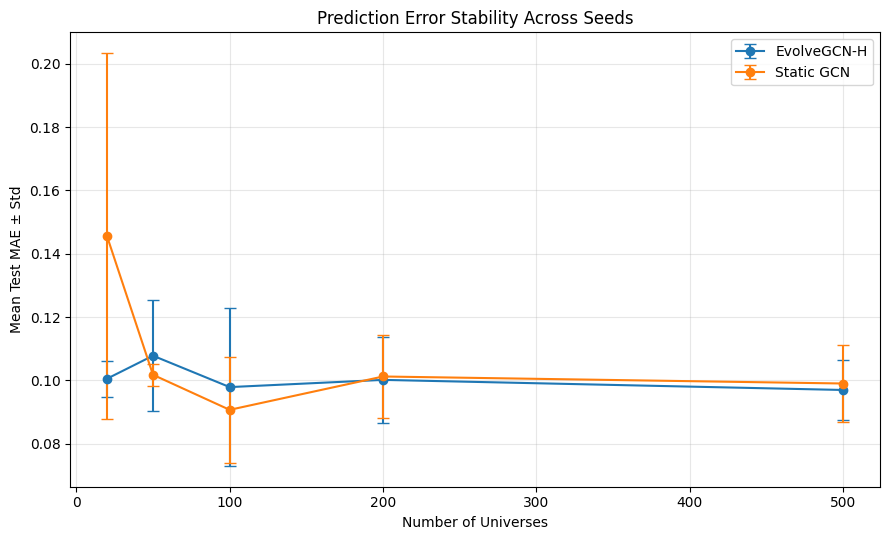

In [32]:
seed_stability = (
    df
    .groupby(["dataset_size", "num_universes_clean", "model"], as_index=False)
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_mae_min=("test_mae", "min"),
        test_mae_max=("test_mae", "max"),
        runs=("seed", "count"),
    )
    .sort_values(["num_universes_clean", "model"])
)

display(seed_stability)

plt.figure(figsize=(9, 5.5))

for model_name, model_df in seed_stability.groupby("model"):
    model_df = model_df.sort_values("num_universes_clean")

    plt.errorbar(
        model_df["num_universes_clean"],
        model_df["test_mae_mean"],
        yerr=model_df["test_mae_std"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel("Number of Universes")
plt.ylabel("Mean Test MAE ± Std")
plt.title("Prediction Error Stability Across Seeds")
plt.grid(True, alpha=0.3)
plt.legend()

save_current_figure("07_seed_stability_test_mae.png")
plt.show()

## 13. Model complexity

This plot compares the number of trainable parameters.

Static GCN is much smaller, while EvolveGCN-H has many more parameters because it evolves graph convolution weights through time using a recurrent mechanism.

This is useful for interpreting results:

- If a larger temporal model performs better, it may be learning useful time evolution.
- If it does not clearly outperform the static model, it may need more data, better tuning, or a different temporal architecture.

,model,trainable_parameters,runs
0,EvolveGCN-H,3409153,15
1,Static GCN,4161,15


MODEL COMPLEXITY INTERPRETATION
Static GCN trainable parameters:   4,161
EvolveGCN-H trainable parameters:  3,409,153
EvolveGCN-H is approximately 819.3x larger than Static GCN.
Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/08_model_complexity_logscale_with_ratio.png


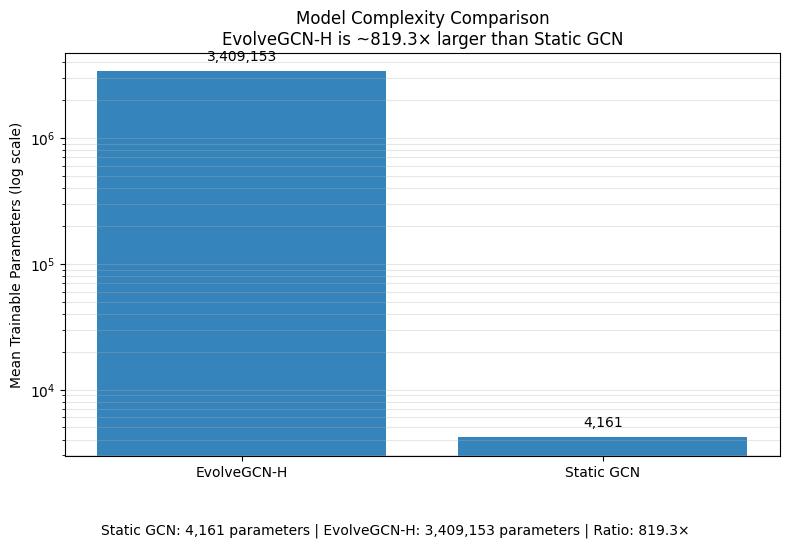

In [40]:
# ============================================================
# Model complexity comparison
# ============================================================

complexity_table = (
    df
    .groupby("model", as_index=False)
    .agg(
        trainable_parameters=("trainable_parameters", "mean"),
        runs=("experiment_name", "count"),
    )
)

# Convert parameter count to integer for cleaner display
complexity_table["trainable_parameters"] = (
    complexity_table["trainable_parameters"]
    .round()
    .astype(int)
)

display(complexity_table)


# ============================================================
# Compute parameter ratio
# ============================================================

static_params = complexity_table.loc[
    complexity_table["model"] == "Static GCN",
    "trainable_parameters"
].iloc[0]

evolve_params = complexity_table.loc[
    complexity_table["model"] == "EvolveGCN-H",
    "trainable_parameters"
].iloc[0]

ratio = evolve_params / static_params

print("=" * 80)
print("MODEL COMPLEXITY INTERPRETATION")
print("=" * 80)
print(f"Static GCN trainable parameters:   {static_params:,}")
print(f"EvolveGCN-H trainable parameters:  {evolve_params:,}")
print(f"EvolveGCN-H is approximately {ratio:.1f}x larger than Static GCN.")
print("=" * 80)


# ============================================================
# Plot with log scale
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    complexity_table["model"],
    complexity_table["trainable_parameters"],
    alpha=0.9,
)

plt.yscale("log")
plt.ylabel("Mean Trainable Parameters (log scale)")
plt.title(f"Model Complexity Comparison\nEvolveGCN-H is ~{ratio:.1f}× larger than Static GCN")
plt.grid(True, axis="y", alpha=0.3, which="both")

# Add exact parameter labels above bars
for bar, val in zip(bars, complexity_table["trainable_parameters"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.15,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Add explanatory text inside the figure
plt.figtext(
    0.5,
    -0.08,
    f"Static GCN: {static_params:,} parameters | "
    f"EvolveGCN-H: {evolve_params:,} parameters | "
    f"Ratio: {ratio:.1f}×",
    ha="center",
    fontsize=10,
)

save_current_figure("08_model_complexity_logscale_with_ratio.png")
plt.show()

## 14. Training curves

Training curves show how the model learns over epochs.

They help check:

- whether the model is still improving,
- whether validation error stops improving,
- whether early stopping was triggered correctly,
- whether the model is overfitting.

A healthy training curve usually shows training loss decreasing and validation loss stabilizing.

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/09_training_curve_500u_evolvegcn_h_seed42.png


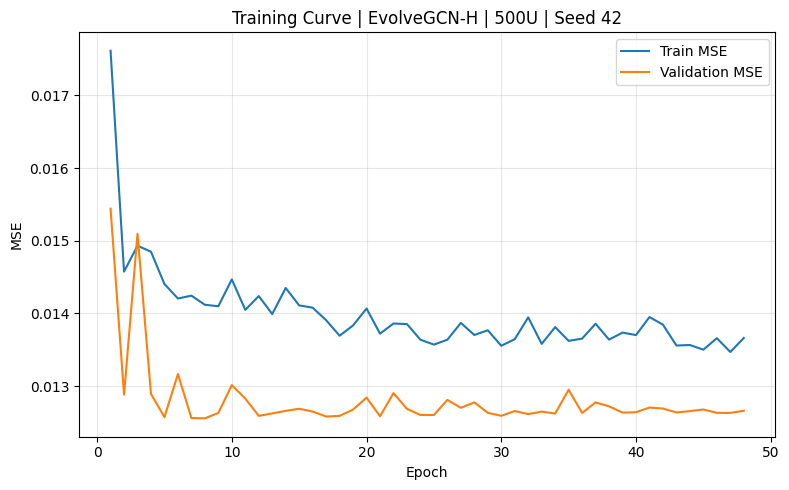

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/09_training_curve_500u_evolvegcn_h_seed123.png


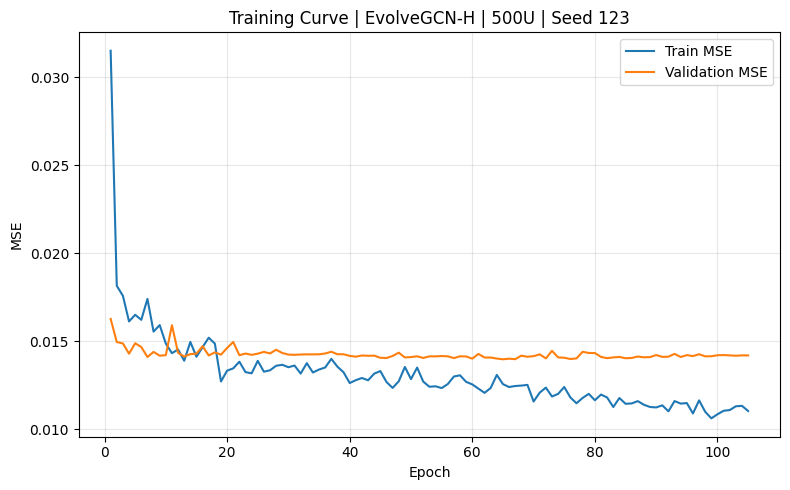

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/09_training_curve_500u_evolvegcn_h_seed2025.png


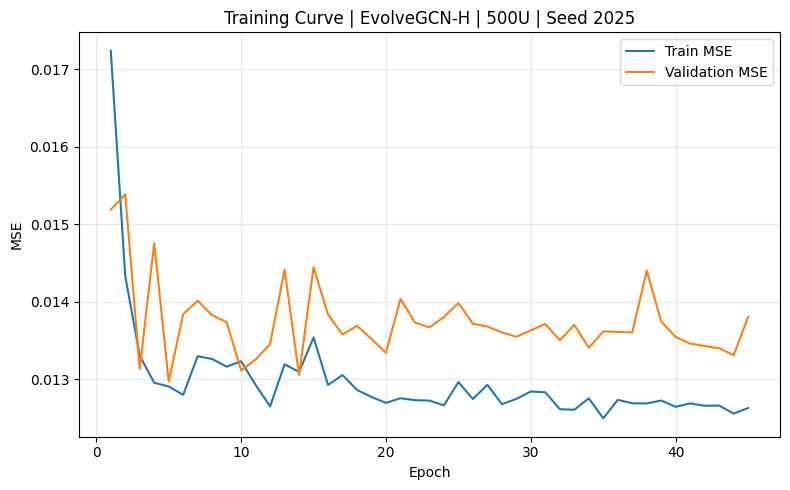

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/09_training_curve_500u_static_gcn_seed42.png


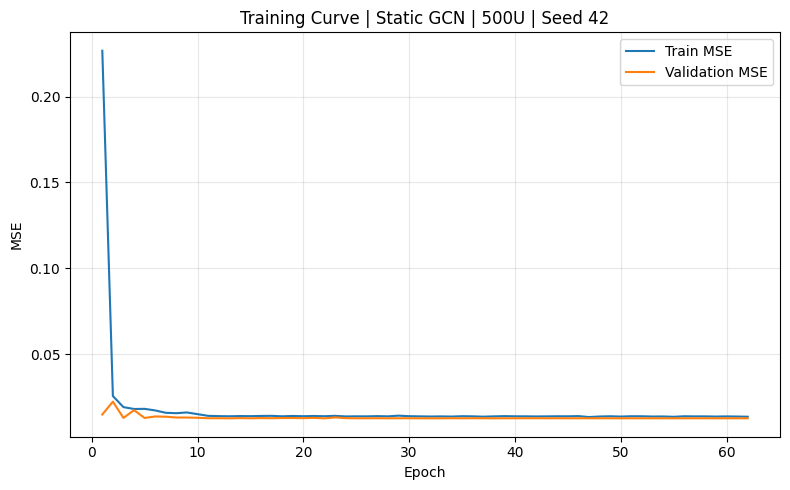

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/09_training_curve_500u_static_gcn_seed123.png


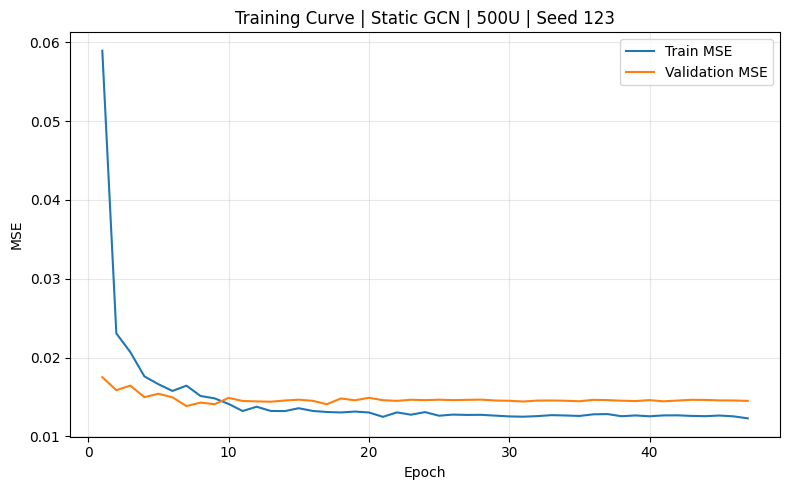

Saved figure: <REPO_ROOT>/outputs/notebook_figures/graph_models_20u_to_500u_no_baseline/09_training_curve_500u_static_gcn_seed2025.png


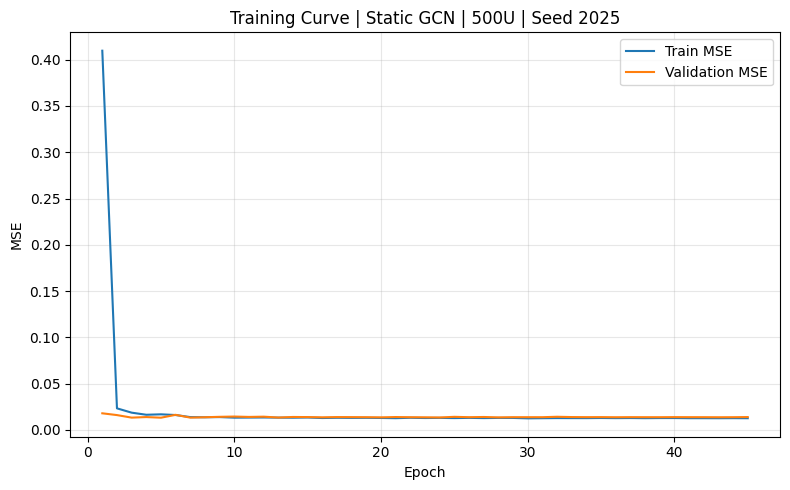

In [35]:
def plot_training_curves_for_500u(summary_df: pd.DataFrame):
    """
    Plot training and validation MSE curves for all 500U experiments.

    Each training script saved a train_log.csv file inside:
        experiments/<experiment_name>/train_log.csv

    Because this notebook runs inside notebooks/visualization, we use PROJECT_ROOT
    to reach the real experiment folder.
    """
    df_500_local = summary_df[summary_df["num_universes_clean"] == 500].copy()

    if df_500_local.empty:
        print("No 500U rows found in the summary table.")
        return

    for _, row in df_500_local.iterrows():
        experiment_dir = PROJECT_ROOT / str(row["experiment_dir"])
        train_log_path = experiment_dir / "train_log.csv"

        if not train_log_path.exists():
            print(f"Missing train log: {train_log_path}")
            continue

        log_df = pd.read_csv(train_log_path)

        required_cols = {"epoch", "train_mse", "val_mse"}
        if not required_cols.issubset(log_df.columns):
            print(f"Train log has missing columns: {train_log_path}")
            print("Columns found:", list(log_df.columns))
            continue

        plt.figure(figsize=(8, 5))

        plt.plot(
            log_df["epoch"],
            log_df["train_mse"],
            label="Train MSE",
        )

        plt.plot(
            log_df["epoch"],
            log_df["val_mse"],
            label="Validation MSE",
        )

        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title(f"Training Curve | {row['model']} | 500U | Seed {int(row['seed'])}")
        plt.grid(True, alpha=0.3)
        plt.legend()

        safe_model_name = (
            str(row["model"])
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        save_current_figure(
            f"09_training_curve_500u_{safe_model_name}_seed{int(row['seed'])}.png"
        )

        plt.show()


plot_training_curves_for_500u(df)

## Final Takeaway

This experiment successfully completes the first large-scale comparison between Static GCN and EvolveGCN-H on CAMELS-SIMBA halo graphs up to 500 universes.

The main result is that both models achieve similar predictive performance on the 500U dataset. EvolveGCN-H is slightly better on average, but the improvement is not large enough to conclude that temporal graph learning is clearly superior under the current settings.

The diagnostic plots show that both models still tend to predict values close to the central $\Omega_m$ region. This indicates partial learning of the cosmological signal, but also a remaining regression-to-the-mean effect.

Therefore, the current result should be interpreted as a successful baseline and scaling experiment, not as the final optimized model. The next research step is to test whether better graph construction improves the prediction. The next experiments will focus on kNN ablations and node-count ablations.